# Policy B: Spread-Front Weed Removal

This notebook validates and evaluates Policy B.

Policy B targets medium-density cells that may drive weed spread into
neighbouring lower-density cells.

For each candidate cell, the policy calculates an outward spread score:

$$
S_i = \sum_{j \in N(i)} \max(W_i - W_j, 0)
$$

where:

- $W_i$ is the weed index of the candidate cell;
- $W_j$ is the weed index of a neighbouring cell;
- $N(i)$ contains the eight neighbouring cells;
- $S_i$ is the outward spread score.

Cells with larger scores are prioritised for treatment.

This notebook performs two checks:

1. Validate Policy B using a small manually defined grid.
2. Compare Policy B with the no-removal baseline using the Perth
   metropolitan dataset.

In [1]:
from pathlib import Path
import os


# Search the current directory and its parents for the repository root.
current_path = Path.cwd().resolve()

repo_root = next(
    path
    for path in (current_path, *current_path.parents)
    if (path / "src").is_dir()
)

# Use the repository root as the working directory.
os.chdir(repo_root)

print(f"Repository root: {repo_root}")
print(f"Current directory: {Path.cwd()}")

Repository root: C:\Users\kazut\Documents\ChatGPT\cits4403_computational_model
Current directory: C:\Users\kazut\Documents\ChatGPT\cits4403_computational_model


## Validate Policy B with a small grid

Before running the full simulation, Policy B is tested independently using
a small manually defined grid.

The test checks that the policy:

- considers only cells within the configured medium-density range;
- calculates differences from the eight neighbouring cells;
- prioritises the cell with the largest outward spread score;
- removes the configured proportion of its weed index;
- calculates the treatment cost correctly.

In [2]:
import importlib

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import src.weed_policies

# Reload the module after editing the Python file.
importlib.reload(src.weed_policies)

from src.weed_policies import (
    SpreadFrontRemovalPolicy,
)

### Create a small test grid

The centre cell has a weed index of `0.6` and is surrounded mainly by cells
with a weed index of `0.1`.

The lower-right cell has a weed index of `0.5`, but it has fewer
lower-density neighbours because it lies on the boundary.

Both cells are within the Policy B range:

$$
0.3 \leq W < 0.7
$$

However, the centre cell has the larger outward spread score and should be
selected first.

In [3]:
# Create a small weed-index grid.
test_grid = np.array(
    [
        [0.10, 0.10, 0.10],
        [0.10, 0.60, 0.10],
        [0.10, 0.10, 0.50],
    ],
    dtype=np.float32,
)

# All cells belong to the test simulation area.
test_mask = np.ones(
    test_grid.shape,
    dtype=bool,
)

print("Weed grid:")
print(test_grid)

print("\nValid mask:")
print(test_mask)

Weed grid:
[[0.1 0.1 0.1]
 [0.1 0.6 0.1]
 [0.1 0.1 0.5]]

Valid mask:
[[ True  True  True]
 [ True  True  True]
 [ True  True  True]]


### Configure Policy B

For this unit check, the policy will:

- consider cells from `0.3` up to, but not including, `0.7`;
- remove `20%` of the selected cell's weed index;
- treat only one cell;
- charge `200` cost units per removed weed-index unit.

Limiting treatment to one cell makes it possible to verify the ranking
directly.

In [4]:
# Configure Policy B for the small-grid check.
policy_b = SpreadFrontRemovalPolicy(
    lower_threshold=0.3,
    upper_threshold=0.7,
    removal_rate=0.2,
    max_cells=1,
    unit_cost=200.0,
)

policy_b

SpreadFrontRemovalPolicy(lower_threshold=0.3, upper_threshold=0.7, removal_rate=0.2, max_cells=1, unit_cost=200.0)

### Apply Policy B

The centre cell should be selected because its weed index is higher than
most of its eight neighbours.

Its removal amount should be:

$$
0.6 \times 0.2 = 0.12
$$

The corresponding cost should be:

$$
0.12 \times 200 = 24
$$

In [6]:
# Apply Policy B directly to the small grid.
removal_grid, treatment_cost = policy_b(
    test_grid,
    test_mask,
)

print("Removal grid:")
print(removal_grid)

print(
    f"\nTreatment cost: "
    f"{treatment_cost:.2f}"
)

Removal grid:
[[0.   0.   0.  ]
 [0.   0.12 0.  ]
 [0.   0.   0.  ]]

Treatment cost: 24.00


In [7]:
# Define the expected removal array.
expected_removal = np.array(
    [
        [0.00, 0.00, 0.00],
        [0.00, 0.12, 0.00],
        [0.00, 0.00, 0.00],
    ],
    dtype=np.float32,
)

# Check the removal grid.
np.testing.assert_allclose(
    removal_grid,
    expected_removal,
    rtol=1e-6,
    atol=1e-6,
)

# Check that exactly one cell was selected.
assert np.count_nonzero(removal_grid) == 1

# Check the treatment cost.
assert np.isclose(
    treatment_cost,
    24.0,
)

print("All Policy B unit checks passed.")

All Policy B unit checks passed.


### Visualise the small-grid result

The panels below show:

1. the weed index before treatment;
2. the removal amount returned by Policy B;
3. the weed index after treatment.

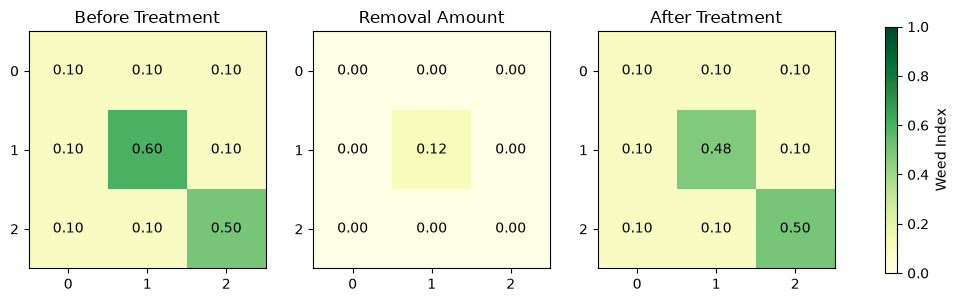

In [8]:
# Apply the returned removal to the test grid.
treated_grid = test_grid - removal_grid

# Preserve invalid cells if the mask is changed later.
treated_grid[~test_mask] = np.nan

cmap = plt.cm.YlGn.copy()
cmap.set_bad("lightgray")

fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(13, 4),
)

images = [
    (test_grid, "Before Treatment"),
    (removal_grid, "Removal Amount"),
    (treated_grid, "After Treatment"),
]

for ax, (grid, title) in zip(axes, images):
    image = ax.imshow(
        grid,
        cmap=cmap,
        vmin=0,
        vmax=1,
    )

    ax.set_title(title)
    ax.set_xticks(range(grid.shape[1]))
    ax.set_yticks(range(grid.shape[0]))

    for row in range(grid.shape[0]):
        for column in range(grid.shape[1]):
            value = grid[row, column]

            if np.isfinite(value):
                ax.text(
                    column,
                    row,
                    f"{value:.2f}",
                    ha="center",
                    va="center",
                    color="black",
                )

fig.colorbar(
    image,
    ax=axes,
    label="Weed Index",
    shrink=0.8,
)

plt.show()

## Run Policy B with the Perth metropolitan data

After validating Policy B independently, it is integrated with the full
weed simulator.

Two simulations are run from identical initial conditions:

- **Baseline:** growth and diffusion only;
- **Policy B:** growth, diffusion and spread-front removal.

The comparison isolates the effect of Policy B.

In [9]:
from src.data_loader import (
    load_locality_data,
)


# Load locality polygons and population-density data.
localities = load_locality_data()

# Select postcodes used as the Perth metropolitan study area.
metro = localities[
    localities["postcode"]
    .astype(int)
    .between(6000, 6199)
].copy()

print(f"Number of polygons: {len(metro)}")
print(f"CRS: {metro.crs}")

metro[
    [
        "name",
        "postcode",
        "population_density_km2",
    ]
].head()

Number of polygons: 375
CRS: EPSG:7844


C:\Users\kazut\Documents\ChatGPT\cits4403_computational_model\src\data_loader.py:28: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  census["postcode"] = (


,name,postcode,population_density_km2
9,PALMYRA,6157,2345.786980
14,EAST FREMANTLE,6158,2106.591326
15,BICTON,6157,2345.786980
28,SUBIACO,6008,2255.266273
33,NORTHBRIDGE,6003,4293.051718


In [10]:
import src.weed_experiment

# Reload the experiment runner after editing its Python file.
importlib.reload(src.weed_experiment)

from src.weed_experiment import (
    ExperimentConfig,
    run_experiment,
)

### Define the shared simulation configuration

The baseline and Policy B use exactly the same simulation parameters.

Both runs use:

- the same population-density input;
- the same initialisation equation;
- the same grid-cell size;
- the same growth and diffusion rates;
- the same number of simulation steps.

The only difference is whether Policy B is registered.

In [11]:
# Define parameters shared by both experiments.
experiment_config = ExperimentConfig(
    pressure_coef=0.000783,
    cell_size=1000.0,
    w_min=0.05,
    w_max=1.0,
    growth_rate=0.02,
    diffusion_rate=0.01,
    carrying_capacity=1.0,
    steps=100,
    high_density_threshold=0.7,
    crs="EPSG:7850",
)

experiment_config

ExperimentConfig(pressure_coef=0.000783, cell_size=1000.0, w_min=0.05, w_max=1.0, growth_rate=0.02, diffusion_rate=0.01, carrying_capacity=1.0, steps=100, high_density_threshold=0.7, crs='EPSG:7850')

### Configure Policy B for the full simulation

During each simulation step, Policy B:

1. selects valid cells with a weed index from `0.3` up to `0.7`;
2. calculates each candidate's outward spread score;
3. ranks candidates by that score;
4. treats at most 100 cells;
5. removes 20% of the selected cells' weed index.

The upper threshold is exclusive, so Policy B does not select the
high-density cells assigned to Policy A.

In [12]:
# Configure Policy B for the full experiment.
policy_b = SpreadFrontRemovalPolicy(
    lower_threshold=0.3,
    upper_threshold=0.7,
    removal_rate=0.2,
    max_cells=100,
    unit_cost=200.0,
)

policy_b

SpreadFrontRemovalPolicy(lower_threshold=0.3, upper_threshold=0.7, removal_rate=0.2, max_cells=100, unit_cost=200.0)

### Run the no-removal baseline

The baseline provides the reference trajectory against which Policy B is
evaluated.

In [13]:
# Run growth and diffusion without a removal policy.
baseline_result = run_experiment(
    name="baseline",
    gdf=metro,
    config=experiment_config,
)

baseline_result.summary()

{'name': 'baseline',
 'steps': 100,
 'grid_height': 203,
 'grid_width': 124,
 'valid_cells': 6933,
 'initial_mean_weed': 0.8605745434761047,
 'final_mean_weed': 0.9814243912696838,
 'relative_change': 0.14042926171791265,
 'final_high_density_cells': 6933,
 'final_cost': 0.0}

### Run Policy B

A new simulator is created for this experiment, so the initial state is
independent of the previously executed baseline.

In [14]:
# Run growth, diffusion and Policy B removal.
policy_b_result = run_experiment(
    name="policy_b",
    gdf=metro,
    config=experiment_config,
    policy=policy_b,
)

policy_b_result.summary()

{'name': 'policy_b',
 'steps': 100,
 'grid_height': 203,
 'grid_width': 124,
 'valid_cells': 6933,
 'initial_mean_weed': 0.8605745434761047,
 'final_mean_weed': 0.8985155820846558,
 'relative_change': 0.04408803269417708,
 'final_high_density_cells': 5854,
 'final_cost': 172316.96875}

## Verify the experiment conditions

The following checks confirm that:

- both experiments started from the same grid;
- the baseline accumulated no treatment cost;
- Policy B's cumulative cost never decreased.

In [15]:
# Both simulations must start from the same initial grid.
np.testing.assert_allclose(
    baseline_result.history[0],
    policy_b_result.history[0],
    equal_nan=True,
)

# The no-removal baseline must have zero final cost.
assert np.isclose(
    baseline_result.final_cost,
    0.0,
)

# Cumulative treatment cost must never decrease.
assert np.all(
    np.diff(policy_b_result.cost_history) >= 0
)

print(
    "The baseline and Policy B started "
    "from identical initial conditions."
)

print(
    "The cumulative cost checks passed."
)

The baseline and Policy B started from identical initial conditions.
The cumulative cost checks passed.


## Compare the summary metrics

The summary table compares:

- the initial mean weed index;
- the final mean weed index;
- the relative change in the mean;
- the final number of high-density cells;
- the cumulative treatment cost.

Policy B may have a weaker immediate effect than Policy A because it does
not directly treat cells whose weed index is `0.7` or greater.

In [16]:
# Combine the two summaries into one comparison table.
comparison = pd.DataFrame(
    [
        baseline_result.summary(),
        policy_b_result.summary(),
    ]
)

comparison[
    [
        "name",
        "initial_mean_weed",
        "final_mean_weed",
        "relative_change",
        "final_high_density_cells",
        "final_cost",
    ]
]

,name,initial_mean_weed,final_mean_weed,relative_change,final_high_density_cells,final_cost
0,baseline,0.860575,0.981424,0.140429,6933,0.00000
1,policy_b,0.860575,0.898516,0.044088,5854,172316.96875


## Compare the mean weed index

This plot shows whether treating medium-density spread-front cells changes
the average weed index across the full simulation area.

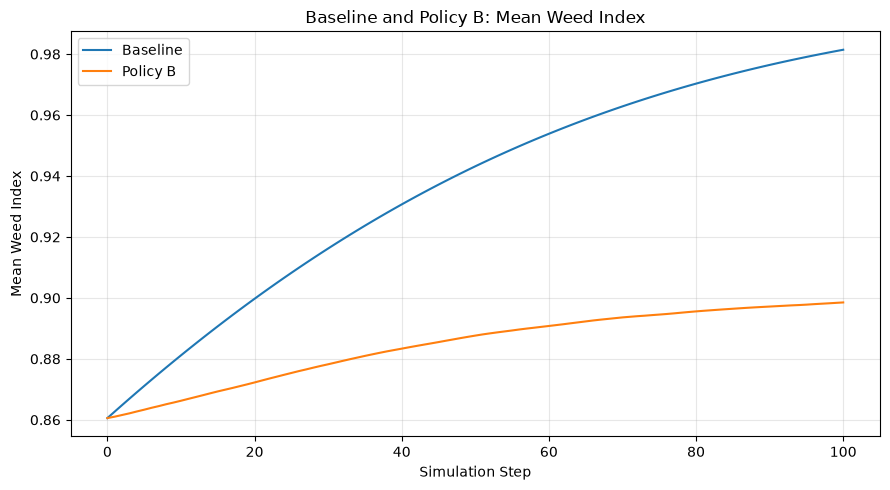

In [17]:
simulation_steps = np.arange(
    len(baseline_result.mean_weed)
)

fig, ax = plt.subplots(
    figsize=(9, 5),
)

ax.plot(
    simulation_steps,
    baseline_result.mean_weed,
    label="Baseline",
)

ax.plot(
    simulation_steps,
    policy_b_result.mean_weed,
    label="Policy B",
)

ax.set_title(
    "Baseline and Policy B: Mean Weed Index"
)

ax.set_xlabel("Simulation Step")
ax.set_ylabel("Mean Weed Index")
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

## Compare high-density cells

Policy B does not directly treat cells with a weed index of `0.7` or
greater.

Instead, it attempts to reduce medium-density sources before they contribute
to further spread. Any effect on high-density cells is therefore indirect.

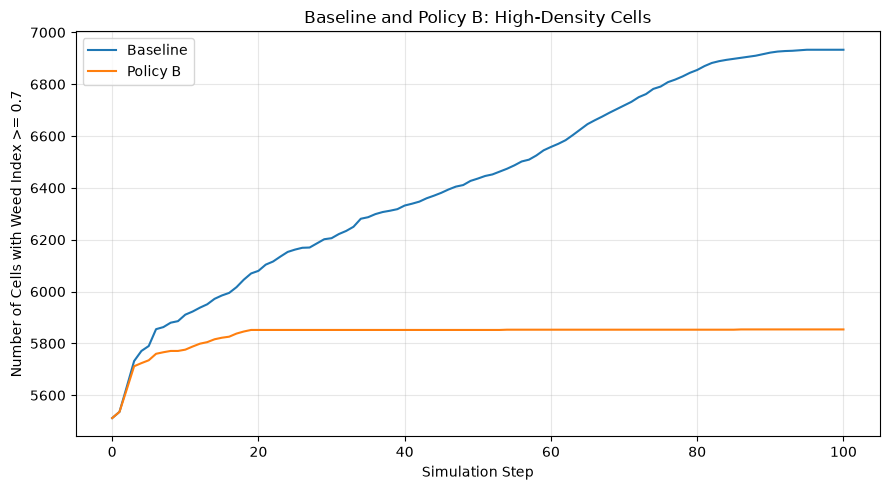

In [18]:
fig, ax = plt.subplots(
    figsize=(9, 5),
)

ax.plot(
    simulation_steps,
    baseline_result.high_density_cells,
    label="Baseline",
)

ax.plot(
    simulation_steps,
    policy_b_result.high_density_cells,
    label="Policy B",
)

ax.set_title(
    "Baseline and Policy B: High-Density Cells"
)

ax.set_xlabel("Simulation Step")
ax.set_ylabel(
    "Number of Cells with Weed Index >= 0.7"
)

ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

## Plot the cumulative treatment cost

Policy B accumulates cost according to the amount of weed index removed.

The curve may not be linear because the number of eligible medium-density
cells and their weed indices can change over time.

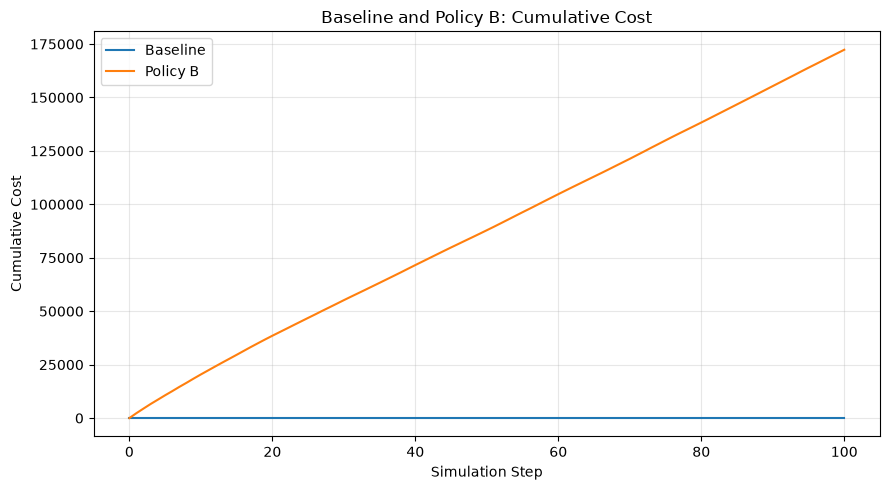

In [19]:
fig, ax = plt.subplots(
    figsize=(9, 5),
)

ax.plot(
    simulation_steps,
    baseline_result.cost_history,
    label="Baseline",
)

ax.plot(
    simulation_steps,
    policy_b_result.cost_history,
    label="Policy B",
)

ax.set_title(
    "Baseline and Policy B: Cumulative Cost"
)

ax.set_xlabel("Simulation Step")
ax.set_ylabel("Cumulative Cost")
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

## Compare the final spatial distributions

The final grids show where Policy B changes the spatial distribution of the
weed index.

Both panels use the same colour scale so that their values can be compared
directly.

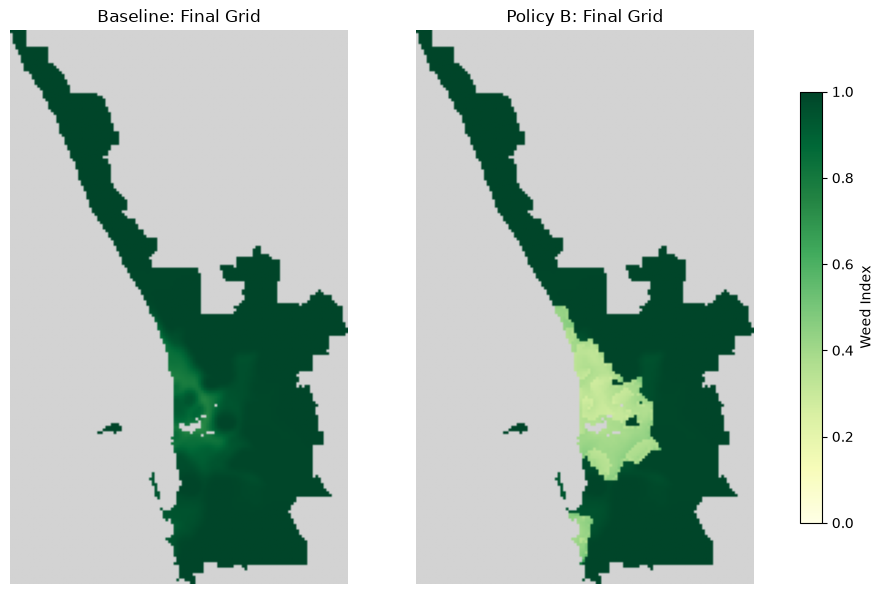

In [20]:
cmap = plt.cm.YlGn.copy()
cmap.set_bad("lightgray")

fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(12, 8),
)

baseline_image = axes[0].imshow(
    baseline_result.history[-1],
    cmap=cmap,
    vmin=0,
    vmax=1,
)

axes[0].set_title("Baseline: Final Grid")
axes[0].axis("off")

axes[1].imshow(
    policy_b_result.history[-1],
    cmap=cmap,
    vmin=0,
    vmax=1,
)

axes[1].set_title("Policy B: Final Grid")
axes[1].axis("off")

fig.colorbar(
    baseline_image,
    ax=axes,
    label="Weed Index",
    shrink=0.7,
)

plt.show()